In [1]:
import ast
import re
import numpy as np
import pandas as pd
from rdkit import Chem
import tensorflow as tf
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
#use in get_data.py
def normalize_graph_features(x):
    x = re.sub(r'(?<=[0-9])\s+(?=[0-9])', ',', x)
    x = re.sub(r'\]\s+\[', '],[', x)
    return x

In [3]:
def preprocess_node_features(node_features_list, valid_atom_types, num_nodes):
    num_features = len(valid_atom_types)
    one_hot_features = np.zeros((num_nodes, num_features))

    atom_type_to_index = {atom: idx for idx, atom in enumerate(valid_atom_types)}

    for i, atom in enumerate(node_features_list):
        if atom[0] in atom_type_to_index:
            one_hot_features[i, atom_type_to_index[atom[0]]] = 1

    return one_hot_features

In [4]:
def pad_adj_matrix(matrix, max_size):
    padded_matrix = np.zeros((max_size, max_size))
    n, m = matrix.shape
    padded_matrix[:n, :m] = matrix
    return padded_matrix

In [5]:
def create_dataset(adj_matrices, one_hot_node_features, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices((one_hot_node_features, adj_matrices))
    dataset = dataset.shuffle(buffer_size=len(one_hot_node_features)).batch(batch_size)
    return dataset

In [6]:
def pad_one_hot_features(features, max_size, num_features):
    padded_features = np.zeros((max_size, num_features))
    n, _ = features.shape
    padded_features[:n, :] = features
    return padded_features

In [7]:
qm9 = pd.read_csv("Data/qm9.csv")
qm9.tail()

,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom,Morgan_fingerprint,adj_matrix,node_features,node_count
133880,gdb_133881,C1C2C3C4C5OC14C5N23,3.59483,2.19899,1.90423,1.6637,69.37,-0.2254,0.0588,0.2842,...,-400.663098,23.658,-1603.983913,-1614.898804,-1623.788097,-1492.819438,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 0 1]\n [...,"[[6], [6], [6], [6], [6], [8], [6], [6], [7]]",9
133881,gdb_133882,C1N2C3C2C2C4OC12C34,3.65648,2.14237,1.90439,1.2976,69.52,-0.2393,0.0608,0.3002,...,-400.658942,23.697,-1601.376613,-1612.291504,-1621.181424,-1490.211511,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 0 1 0]\n [1 0 1 1 0 0 0 0 0]\n [...,"[[6], [7], [6], [6], [6], [6], [8], [6], [6]]",9
133882,gdb_133883,C1N2C3C4C5C2C13CN45,3.67118,2.14314,1.89501,1.2480,73.60,-0.2233,0.0720,0.2953,...,-380.783148,23.972,-1667.045429,-1678.830048,-1688.312964,-1549.143391,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 1 0 0 0]\n [...,"[[6], [7], [6], [6], [6], [6], [6], [6], [7]]",9
133883,gdb_133884,C1N2C3C4C5CC13C2C45,3.52845,2.15131,1.86582,1.9576,77.40,-0.2122,0.0881,0.3003,...,-364.749650,24.796,-1794.600439,-1807.210860,-1817.286772,-1670.349892,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 1 0]\n [...,"[[6], [7], [6], [6], [6], [6], [6], [6], [6]]",9
133884,gdb_133885,C1N2C3C4C5OC13C2C45,3.64015,2.21764,1.93793,0.8626,69.48,-0.2316,0.0742,0.3058,...,-400.662186,23.434,-1603.471865,-1614.455155,-1623.345075,-1492.247150,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 1 0]\n [...,"[[6], [7], [6], [6], [6], [8], [6], [6], [6]]",9


In [8]:
#use in get_data.py
qm9['adj_matrix'] = qm9["adj_matrix"].apply(normalize_graph_features)
qm9['node_features'] = qm9["node_features"].apply(normalize_graph_features)

In [9]:
#use in get_data.py
qm9['adj_matrix'] = qm9['adj_matrix'].apply(lambda x: np.array(ast.literal_eval(x)))
qm9['node_features'] = qm9['node_features'].apply(lambda x: ast.literal_eval(x))

In [10]:
valid_atom_types = [1, 6, 7, 8, 9]
num_features = len(valid_atom_types)

one_hot_node_features = [
    preprocess_node_features(nf, valid_atom_types, num_nodes)
    for nf, num_nodes in zip(qm9['node_features'], qm9['node_count'])
]

In [11]:
max_size = max(matrix.shape[0] for matrix in qm9['adj_matrix'])
qm9['adj_matrix'] = qm9['adj_matrix'].apply(lambda x: pad_adj_matrix(x, max_size))

In [12]:
one_hot_node_features = [
    pad_one_hot_features(features, max_size, num_features)
    for features in one_hot_node_features
]

In [13]:
adj_matrices = np.stack(qm9['adj_matrix'].values)
one_hot_node_features = np.stack(one_hot_node_features)

In [96]:
adj_matrices_small = adj_matrices[:1000]
one_hot_node_features_small = one_hot_node_features[:1000]

dataset_small = create_dataset(adj_matrices_small, one_hot_node_features_small, batch_size=32)

In [93]:
dataset = create_dataset(adj_matrices, one_hot_node_features, batch_size=32)

In [99]:
class GraphGenerator(tf.keras.Model):
  def __init__(self, num_nodes, node_features, latent_dim):
     super().__init__()

     self.num_nodes = num_nodes
     self.node_features = node_features
     self.latent_dim = latent_dim

     self.mlp = models.Sequential([
         layers.Dense(128, input_shape = (latent_dim,), activation="relu"),
         layers.Dense(256, activation = "relu"),
         layers.Dense((num_nodes * num_nodes) + (num_nodes * node_features), activation = "softmax")
     ])

     self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

  def call(self, z):
    batch_size = tf.shape(z)[0]

    output = self.mlp(z)

    adj_flat = output[:, :self.num_nodes * self.num_nodes]
    adj_flat = tf.nn.sigmoid(adj_flat)
    node_feature_flat = output[:, self.num_nodes * self.num_nodes:]

    adj = tf.reshape(adj_flat, (batch_size, self.num_nodes, self.num_nodes))
    adj = (adj + tf.transpose(adj, perm=[0, 2, 1])) / 2
    adj = tf.nn.softmax(adj, axis=-1)
    adj = tf.cast(adj, tf.float32)

    valid_atom_types = tf.constant([1, 6, 7, 8, 9], dtype = tf.int64)

    node_features = tf.reshape(node_feature_flat, (batch_size, self.num_nodes, self.node_features))
    node_features = tf.nn.softmax(node_features, axis = -1)
    node_features = tf.clip_by_value(node_features, 0, 4)
    node_features = tf.cast(node_features, tf.int32)
    node_features = tf.gather(valid_atom_types, node_features)
    node_features = tf.cast(node_features, tf.float32)

    return adj, node_features

  def loss_function(self, real_output, fake_output):
    loss_func = tf.keras.losses.BinaryCrossentropy(from_logits = False)
    return loss_func(real_output, fake_output)
  
  def fit(self, dataset, discriminator, epochs=10):
    d_loss_list = []
    g_loss_list = []

    for epoch in range(epochs):
      for batch_idx, (real_node_features, real_adj) in enumerate(dataset):
        z = tf.random.normal([tf.shape(real_node_features)[0], self.latent_dim])
        gen_adj, gen_node_features = self.call(z)
        
        with tf.GradientTape() as tape:
          fake_output = discriminator.call(gen_adj, gen_node_features)
          real_output = discriminator.call(real_adj, real_node_features)

          #label smoothing test
          real_labels = tf.ones_like(real_output) * .9
          fake_labels = tf.zeros_like(fake_output) + .1

          real_labels = tf.ones_like(real_output)
          fake_labels = tf.zeros_like(fake_output)

          #label switching test
          if np.random.rand() < .05:
            real_labels, fake_labels = fake_labels, real_labels

          d_loss = self.loss_function(real_labels, real_output) + \
            self.loss_function(fake_labels, fake_output)
          
          d_loss_list.append(d_loss.numpy())

        gradients = tape.gradient(d_loss, discriminator.mlp.trainable_variables)
        discriminator.optimizer.apply_gradients(zip(gradients, discriminator.mlp.trainable_variables))

        for _ in range(3):  
          z = tf.random.normal([tf.shape(real_node_features)[0], self.latent_dim])

          with tf.GradientTape() as tape:
            gen_adj, gen_node_features = self(z)
            fake_output = discriminator(gen_adj, gen_node_features)
            g_loss = self.loss_function(tf.ones_like(fake_output), fake_output)

            g_loss_list.append(g_loss.numpy())
            
          gradients = tape.gradient(g_loss, self.mlp.trainable_variables)
          self.optimizer.apply_gradients(zip(gradients, self.mlp.trainable_variables))

          if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}, "
            f"D Loss: {d_loss.numpy():.4f}, G Loss: {g_loss.numpy():.4f}")

    return d_loss_list, g_loss_list

          #print(f"Epoch {epoch+1}/{epochs} completed.")

In [86]:
class GraphDiscriminator(tf.keras.Model):
    def __init__(self, num_nodes, node_features):
        super().__init__()
        self.input_dim = num_nodes * num_nodes
        self.condition_dim = num_nodes * node_features

        self.mlp = models.Sequential([
            layers.Dense(256, input_shape = (self.input_dim + self.condition_dim,), activation='leaky_relu'),
            layers.Dense(128, activation='leaky_relu'),
            layers.BatchNormalization(),
            layers.Dense(1, activation='sigmoid')
        ])

        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

    def call(self, adj, node_features):
        batch_size = tf.shape(adj)[0]

        adj_flat = tf.reshape(adj, (batch_size, self.input_dim))
        node_features_flat = tf.reshape(node_features, (batch_size, self.condition_dim))

        combined = tf.concat([adj_flat, node_features_flat], axis = 1)

        validity = self.mlp(combined)

        return validity

In [87]:
def adjacency_matrix_to_mol(inp_matrix):
  mol = Chem.RWMol()
  atom_types = np.unique(inp_matrix[1])
  matrix = inp_matrix[0]
  atom_map = {i: mol.AddAtom(Chem.Atom(int(atom_types[i]))) for i in range(len(atom_types))}

  if isinstance(matrix, tf.Tensor):
        matrix = matrix.numpy()
  if isinstance(atom_types, tf.Tensor):
      atom_types = atom_types.numpy()

  matrix = np.array(matrix)
  atom_types = np.array(atom_types)

  if len(matrix) != len(atom_types):
    raise ValueError("NUMBER OF ATOM TYPES DOES NOT MATCH MATRIX DIMENSIONS")

  # Step 1: Add Atoms
  for i, atom_num in enumerate(atom_types):
    atom = Chem.Atom(int(atom_num))
    mol_idx = mol.AddAtom(atom)
    atom_map[i] = mol_idx

  # Step 2: Add Bonds
  for i in range(len(matrix)):
    for j in range(i + 1, len(matrix)):
        if j not in atom_map:
            continue

        value = int(np.argmax(matrix[i, j]))
        value = min(max(value, 0), 4)

        if value != 0:
            bond_type = {
                1: Chem.BondType.SINGLE,
                2: Chem.BondType.DOUBLE,
                3: Chem.BondType.TRIPLE,
                4: Chem.BondType.AROMATIC
            }.get(value, None)

            if bond_type is None:
                raise ValueError(f"INVALID BOND TYPE DETECTED: {value}")

            print(f"Adding bond: {i}-{j} Type: {bond_type}")
            mol.AddBond(atom_map[i], atom_map[j], bond_type)

  return mol

In [100]:
generator = GraphGenerator(num_nodes=max_size, node_features=num_features, latent_dim=128)
discriminator = GraphDiscriminator(num_nodes=max_size, node_features=num_features)

d_loss, g_loss = generator.fit(dataset_small, discriminator, epochs=10)

Epoch 1/10, Batch 0, D Loss: 1.3277, G Loss: 0.7730
Epoch 1/10, Batch 0, D Loss: 1.3277, G Loss: 0.7730
Epoch 1/10, Batch 0, D Loss: 1.3277, G Loss: 0.7730
Epoch 1/10, Batch 10, D Loss: 0.6818, G Loss: 1.5534
Epoch 1/10, Batch 10, D Loss: 0.6818, G Loss: 1.5534
Epoch 1/10, Batch 10, D Loss: 0.6818, G Loss: 1.5534
Epoch 1/10, Batch 20, D Loss: 0.3846, G Loss: 2.1734
Epoch 1/10, Batch 20, D Loss: 0.3846, G Loss: 2.1734
Epoch 1/10, Batch 20, D Loss: 0.3846, G Loss: 2.1734
Epoch 1/10, Batch 30, D Loss: 0.2179, G Loss: 2.7108
Epoch 1/10, Batch 30, D Loss: 0.2179, G Loss: 2.7108
Epoch 1/10, Batch 30, D Loss: 0.2179, G Loss: 2.7108
Epoch 2/10, Batch 0, D Loss: 4.9443, G Loss: 2.4564
Epoch 2/10, Batch 0, D Loss: 4.9443, G Loss: 2.4564
Epoch 2/10, Batch 0, D Loss: 4.9443, G Loss: 2.4564
Epoch 2/10, Batch 10, D Loss: 0.2538, G Loss: 2.1997
Epoch 2/10, Batch 10, D Loss: 0.2538, G Loss: 2.1997
Epoch 2/10, Batch 10, D Loss: 0.2538, G Loss: 2.1997
Epoch 2/10, Batch 20, D Loss: 0.1920, G Loss: 2.6011

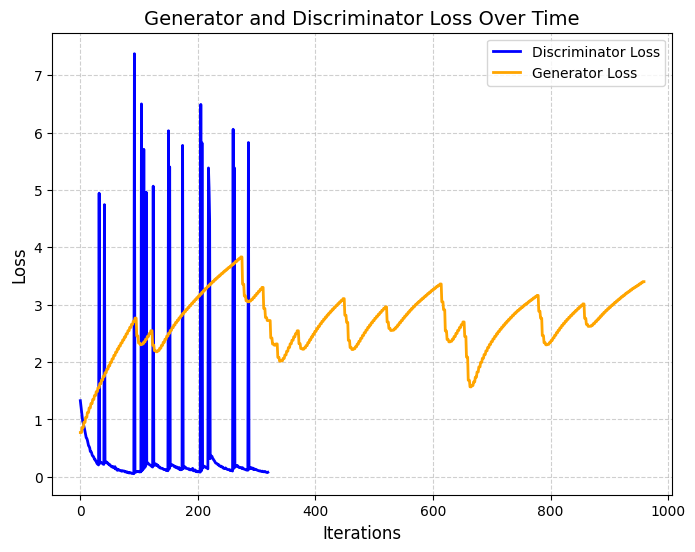

In [101]:
plt.figure(figsize=(8, 6)) 
plt.plot(d_loss, label="Discriminator Loss", color="blue", linewidth=2)  
plt.plot(g_loss, label="Generator Loss", color="orange", linewidth=2)  

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Generator and Discriminator Loss Over Time", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6) 

plt.show()

### Notes
    smoothing reduced the high generator loss and made the discriminator loss not go as low

    random flipping of the labels cuased the spikes in loss for the discriminator and made the generator stagnat and not go as high